In [92]:
!pip install -q kagglehub


In [93]:
import kagglehub

path = kagglehub.dataset_download(
    "marquis03/bean-leaf-lesions-classification",
    output_dir="/content/bean-leaf-lesions"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'bean-leaf-lesions-classification' dataset.
Dataset downloaded to: /kaggle/input/bean-leaf-lesions-classification


In [94]:
!find /content/bean-leaf-lesions -maxdepth 2 -type d

/content/bean-leaf-lesions
/content/bean-leaf-lesions/.complete
/content/bean-leaf-lesions/.complete/datasets
/content/bean-leaf-lesions/train
/content/bean-leaf-lesions/train/angular_leaf_spot
/content/bean-leaf-lesions/train/bean_rust
/content/bean-leaf-lesions/train/healthy
/content/bean-leaf-lesions/val
/content/bean-leaf-lesions/val/angular_leaf_spot
/content/bean-leaf-lesions/val/bean_rust
/content/bean-leaf-lesions/val/healthy


In [95]:
import torch
from torch import nn
from torch.optim import Adam
from  torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
device = "cuda" if torch.cuda.is_available() else    "cpu"

In [96]:
train_df = pd.read_csv("/content/bean-leaf-lesions/train.csv")
val_df = pd.read_csv("/content/bean-leaf-lesions/val.csv")
train_df["image:FILE"] = "/content/bean-leaf-lesions/" +   train_df["image:FILE"]
val_df["image:FILE"] = "/content/bean-leaf-lesions/" +   val_df["image:FILE"]

train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions/train/healthy/healt...,0
1,/content/bean-leaf-lesions/train/healthy/healt...,0
2,/content/bean-leaf-lesions/train/healthy/healt...,0
3,/content/bean-leaf-lesions/train/healthy/healt...,0
4,/content/bean-leaf-lesions/train/healthy/healt...,0


In [97]:
train_df["category"].unique()

array([0, 1, 2])

In [98]:
print(train_df.shape)

(1034, 2)


In [99]:
print(val_df.shape)

(133, 2)


In [100]:
print(train_df["category"].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [101]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [102]:
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe["category"].values).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    # Using the absolute path directly from the dataframe
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert("RGB")
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

In [103]:
train_dataset = CustomImageDataset(dataframe=train_df, transform=transform)
val_dataset = CustomImageDataset(dataframe=val_df, transform=transform)

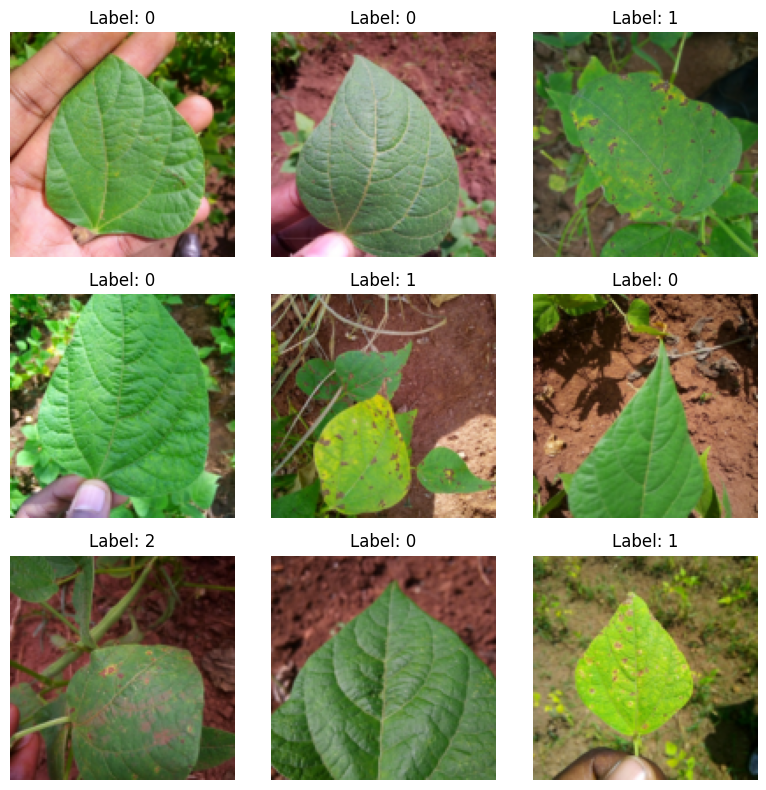

In [104]:
import numpy as np

n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols, figsize=(8, 8))
for row in range(n_rows):
    for col in range(n_cols):
      # Randomly select an image
      random_idx = np.random.randint(0, len(train_dataset))
      image, label = train_dataset[random_idx]
      image = image.cpu()

      # Permute the dimensions from (C, H, W) to (H, W, C) for plotting
      axarr[row, col].imshow(image.permute(1, 2, 0))
      axarr[row, col].set_title(f"Label: {label.item()}")
      axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

In [105]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

In [106]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [107]:
googlenet_model = models.googlenet(weights="DEFAULT")


In [108]:
for param in googlenet_model.parameters():
  param.requires_grad = True


In [109]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [110]:
num_classes = len(train_df["category"].unique())
num_classes

3

In [111]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [112]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [113]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

In [114]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs , label in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, label)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs,axis = 1) == label).sum().item()
    total_acc_train += train_acc

    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))
  print(f"epoch:{epoch+1}/{EPOCHS},train_loss:{round(total_loss_train/1000,4)},train_accuracy :{round(total_acc_train/train_dataset.__len__()*100,4)}%")

epoch:1/15,train_loss:0.2124,train_accuracy :67.118%
epoch:2/15,train_loss:0.1641,train_accuracy :74.8549%
epoch:3/15,train_loss:0.1294,train_accuracy :80.3675%
epoch:4/15,train_loss:0.1115,train_accuracy :84.5261%
epoch:5/15,train_loss:0.1168,train_accuracy :83.9458%
epoch:6/15,train_loss:0.0783,train_accuracy :89.1683%
epoch:7/15,train_loss:0.0803,train_accuracy :89.265%
epoch:8/15,train_loss:0.0654,train_accuracy :91.4894%
epoch:9/15,train_loss:0.0786,train_accuracy :89.8453%
epoch:10/15,train_loss:0.0587,train_accuracy :91.3926%
epoch:11/15,train_loss:0.0541,train_accuracy :93.5203%
epoch:12/15,train_loss:0.0588,train_accuracy :92.5532%
epoch:13/15,train_loss:0.0466,train_accuracy :93.7137%
epoch:14/15,train_loss:0.0441,train_accuracy :94.8743%
epoch:15/15,train_loss:0.0316,train_accuracy :95.5513%


In [116]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, label in val_loader:
    predictions   = googlenet_model(inputs)
    acc = (torch.argmax(predictions,axis=1)==label).sum().item()
    total_acc_test += acc

In [117]:
print(round(total_acc_test)/val_dataset.__len__()*100,2)

93.23308270676691 2


# transfer learning

In [119]:
googlenet_model = models.googlenet(weights = "DEFAULT")

for param in googlenet_model.parameters():
  param.requires_grad = False

googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc.requires_grad = True
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [120]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs , label in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, label)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs,axis = 1) == label).sum().item()
    total_acc_train += train_acc

    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))
  print(f"epoch:{epoch+1}/{EPOCHS},train_loss:{round(total_loss_train/1000,4)},train_accuracy :{round(total_acc_train/train_dataset.__len__()*100,4)}%")

epoch:1/15,train_loss:0.3003,train_accuracy :29.1103%
epoch:2/15,train_loss:0.295,train_accuracy :31.8182%
epoch:3/15,train_loss:0.2991,train_accuracy :29.7872%
epoch:4/15,train_loss:0.2976,train_accuracy :30.1741%
epoch:5/15,train_loss:0.2983,train_accuracy :29.207%
epoch:6/15,train_loss:0.298,train_accuracy :29.6905%
epoch:7/15,train_loss:0.298,train_accuracy :30.2708%
epoch:8/15,train_loss:0.2977,train_accuracy :30.2708%
epoch:9/15,train_loss:0.2967,train_accuracy :28.7234%
epoch:10/15,train_loss:0.296,train_accuracy :30.4642%
epoch:11/15,train_loss:0.2976,train_accuracy :30.4642%
epoch:12/15,train_loss:0.3001,train_accuracy :29.8839%
epoch:13/15,train_loss:0.2996,train_accuracy :28.0464%
epoch:14/15,train_loss:0.2975,train_accuracy :30.2708%
epoch:15/15,train_loss:0.2959,train_accuracy :30.2708%


In [121]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, label in val_loader:
    predictions   = googlenet_model(inputs)
    acc = (torch.argmax(predictions,axis=1)==label).sum().item()
    total_acc_test += acc

In [122]:
print(round(total_acc_test)/val_dataset.__len__()*100,2)

26.31578947368421 2
